In [1]:
import os
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../sample_data"
MODEL_PREDICTIONS = f"{DATA_PATH}/model_predictions"
meta_data = pd.read_excel(f'{DATA_PATH}/V5ModelSummary_CAWA.xlsx', sheet_name=['species', 'regions', 'variables', 'importance', 'validation', 'abundances'])

In [3]:
meta_data.keys()

dict_keys(['species', 'regions', 'variables', 'importance', 'validation', 'abundances'])

In [4]:
files = os.listdir(MODEL_PREDICTIONS)
files

['CAWA_Lower48_2020.tif',
 'CAWA_Canada_2010.tif',
 'CAWA_Canada_2005.tif',
 'CAWA_Canada_2015.tif',
 'CAWA_Canada_2000.tif',
 'CAWA_Lower48_1990.tif',
 'CAWA_Lower48_1995.tif',
 'CAWA_Canada_1995.tif',
 'CAWA_Canada_1990.tif',
 'CAWA_Lower48_2000.tif',
 'CAWA_Lower48_2015.tif',
 'CAWA_Canada_2020.tif',
 'CAWA_Lower48_2005.tif',
 'CAWA_Lower48_2010.tif']

In [5]:
keys = [f.replace(".tif", "").replace("CAWA_", "") for f in files]

datasets = {}
for key, file in zip(keys, files):
    datasets[key] = rasterio.open(f"{MODEL_PREDICTIONS}/{file}")
datasets

{'Lower48_2020': <open DatasetReader name='../sample_data/model_predictions/CAWA_Lower48_2020.tif' mode='r'>,
 'Canada_2010': <open DatasetReader name='../sample_data/model_predictions/CAWA_Canada_2010.tif' mode='r'>,
 'Canada_2005': <open DatasetReader name='../sample_data/model_predictions/CAWA_Canada_2005.tif' mode='r'>,
 'Canada_2015': <open DatasetReader name='../sample_data/model_predictions/CAWA_Canada_2015.tif' mode='r'>,
 'Canada_2000': <open DatasetReader name='../sample_data/model_predictions/CAWA_Canada_2000.tif' mode='r'>,
 'Lower48_1990': <open DatasetReader name='../sample_data/model_predictions/CAWA_Lower48_1990.tif' mode='r'>,
 'Lower48_1995': <open DatasetReader name='../sample_data/model_predictions/CAWA_Lower48_1995.tif' mode='r'>,
 'Canada_1995': <open DatasetReader name='../sample_data/model_predictions/CAWA_Canada_1995.tif' mode='r'>,
 'Canada_1990': <open DatasetReader name='../sample_data/model_predictions/CAWA_Canada_1990.tif' mode='r'>,
 'Lower48_2000': <open

In [6]:
for k in keys:
    datasets[k].read()

the predictions might be "Time-matched predictors for vegetation biomass, human disturbance, and annual climate"

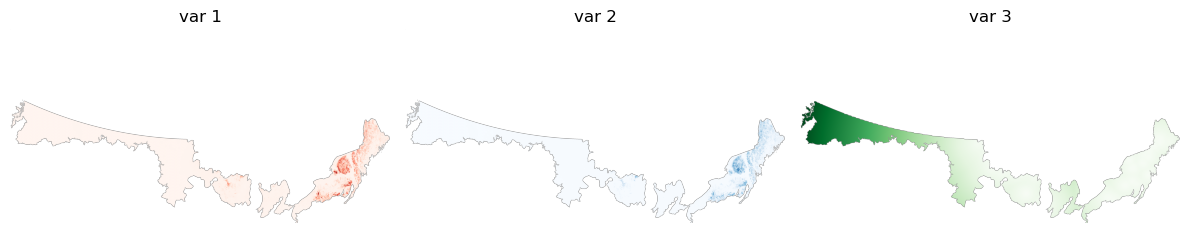

In [9]:
data = datasets[k].read()
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
cmaps = ["Reds", "Blues", "Greens"]
bands = ["var 1", "var 2", "var 3"]
for band in [0, 1, 2]:
    ax[band].imshow(data[band, :, :], cmap=cmaps[band])
    ax[band].set_title(bands[band])
    ax[band].axis("off")
plt.tight_layout();

In [10]:
os.listdir(DATA_PATH)

['model_objects',
 '.DS_Store',
 'model_predictions',
 'SpeciesData_Rounded.csv',
 'V5ModelSummary_CAWA.xlsx']